#  Problem 

### Problem
$$
\begin{align*}
u(x, y) &= x^{3} e^{x} (y + 1) \cos(x + y^{3}).
\end{align*}
$$

From the Paper:

In contrast with Problem 3, here we adopt a solution without symmetries:

Table VI presents relative errors for the Dirichlet and Neumann problems in the disk $B(0; 1)$.

The same problem was solved in the larger disk $B(0; 2)$, and the numerical results are shown in Table VII.

Clearly, the solution in the larger domain (even using twice the number of Fourier coefficients) presents a lower accuracy when compared with the same number of circles for $B(0; 1)$.

# Imports

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Tests.JCP_Paper_Comparisons.JCP_Helpers import (
    get_problem_functions,
    run_table_2,
    display_table_varying_M
)




# Problem Setup

In [2]:
# Problem Setup — Problem 4 (Borges–Daripa JCP)

# Radii for Tables 6 and 7
R1 = 1.0    # unit disk B(0,1)
R2 = 2.0    # larger disk B(0,2)

# Radial mesh type: keep radial grid uniform here
rad_unif = 1

x, y = sp.symbols('x y')
u_sym = x**3 * sp.exp(x) * (y + 1.0) * sp.cos(x + y**3)
u, f, g_dirichlet, g_neumann = get_problem_functions(u_sym, x, y)

# N and M values (Paper states Table 7 uses twice the Fourier coefficients of Table 6)
M_values = [64, 128, 256, 512, 1024, 2048]
N_fixed_R1 = 64
N_fixed_R2 = 128

# ----------------------------------------------------------
# Methods to test
# ----------------------------------------------------------
methods = [
    dict(
        name="uniform_fft",
        label="Uniform Mesh",
        azu_unif=2,
        mesh_kind=None,
        use_nudft=None,
    ),
]

BC_MAP = {
    "dirichlet": 1,
    "neumann": 2,
}

QUAD_MAP = {
    "trapezoidal": 1,
    "simpson": 2,
}

# Run Code, table 

In [3]:
# Table 6: R = R1 (unit disk), N = 64
df_table6 = run_table_2(methods, N_fixed_R1, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R1)

# Table 7: R = R2 (B(0,2)), N = 128
df_table7 = run_table_2(methods, N_fixed_R2, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R2)


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


# View Results

In [4]:
display_table_varying_M(df_table6, methods, M_values, f"TABLE 6 (Problem 4, R = {R1})")
display_table_varying_M(df_table7, methods, M_values, f"TABLE 7 (Problem 4, R = {R2})")



Uniform Mesh : TABLE 6 (Problem 4, R = 1.0)


Trapezoidal rule                             Simpson rule           \
            Dirichlet            Neumann             Dirichlet            
            L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                         
64            1.3e-04  2.1e-04   8.7e-04  1.3e-03      2.2e-05  4.5e-05   
128           3.1e-05  5.1e-05   2.1e-04  3.1e-04      2.7e-06  5.7e-06   
256           7.7e-06  1.3e-05   5.3e-05  7.7e-05      3.4e-07  7.1e-07   
512           1.9e-06  3.2e-06   1.3e-05  1.9e-05      4.2e-08  8.8e-08   
1024          4.8e-07  7.9e-07   3.3e-06  4.8e-06      5.3e-09  1.1e-08   
2048          1.2e-07  2.0e-07   8.2e-07  1.2e-06      6.6e-10  1.4e-09   

                         
       Neumann           
     L_inf_rel   L2_rel  
M                        
64     2.6e-05  3.7e-05  
128    3.2e-06  4.5e-06  
256    4.0e-07  5.6e-07  
512    5.0e-08  7.0e-08  
1024   6.2e-09  8.7e-09  
2048   7.7e-10  1.1e-09


Uniform Mesh : TABLE 7 (Problem 4, R = 2.0)


Trapezoidal rule                             Simpson rule           \
            Dirichlet            Neumann             Dirichlet            
            L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                         
64            5.4e-04  1.2e-03   3.7e-03  5.9e-03      2.6e-04  3.6e-04   
128           1.3e-04  2.9e-04   9.2e-04  1.5e-03      3.4e-05  3.9e-05   
256           3.3e-05  7.2e-05   2.3e-04  3.6e-04      4.3e-06  4.6e-06   
512           8.2e-06  1.8e-05   5.7e-05  9.0e-05      5.3e-07  5.6e-07   
1024          2.0e-06  4.4e-06   1.4e-05  2.3e-05      6.7e-08  6.8e-08   
2048          5.1e-07  1.1e-06   3.5e-06  5.6e-06      8.4e-09  8.5e-09   

                         
       Neumann           
     L_inf_rel   L2_rel  
M                        
64     3.1e-04  2.6e-04  
128    3.8e-05  3.0e-05  
256    4.7e-06  3.6e-06  
512    5.8e-07  4.5e-07  
1024   7.2e-08  5.6e-08  
2048   9.0e-09  6.9e-09

## Figures from Original Paper

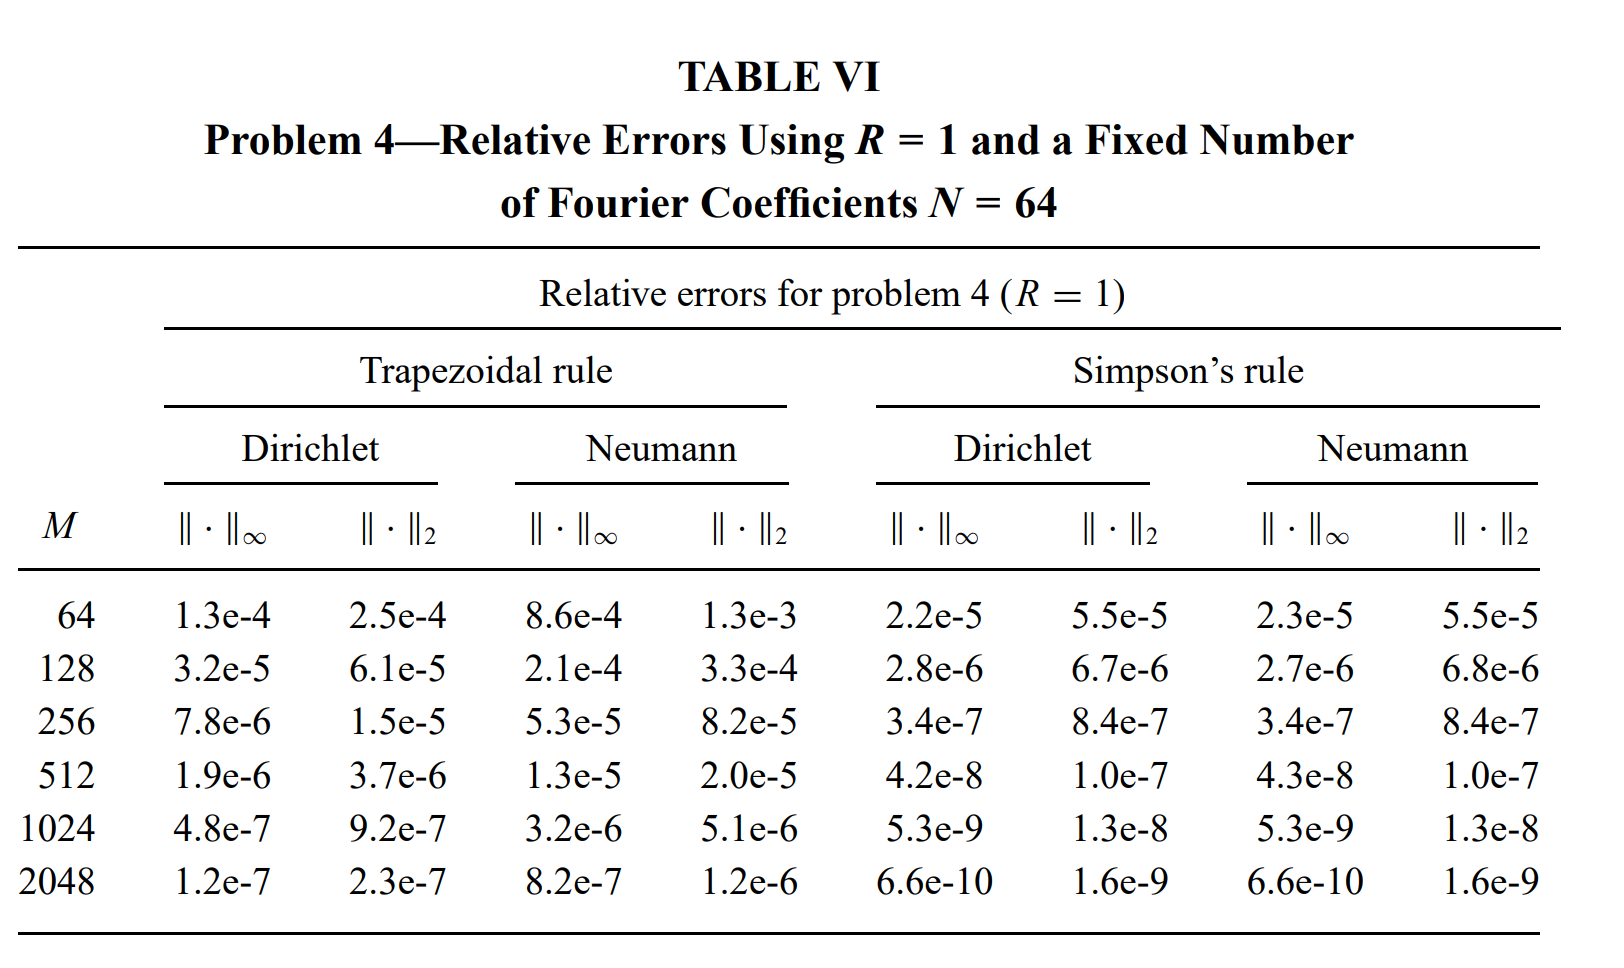

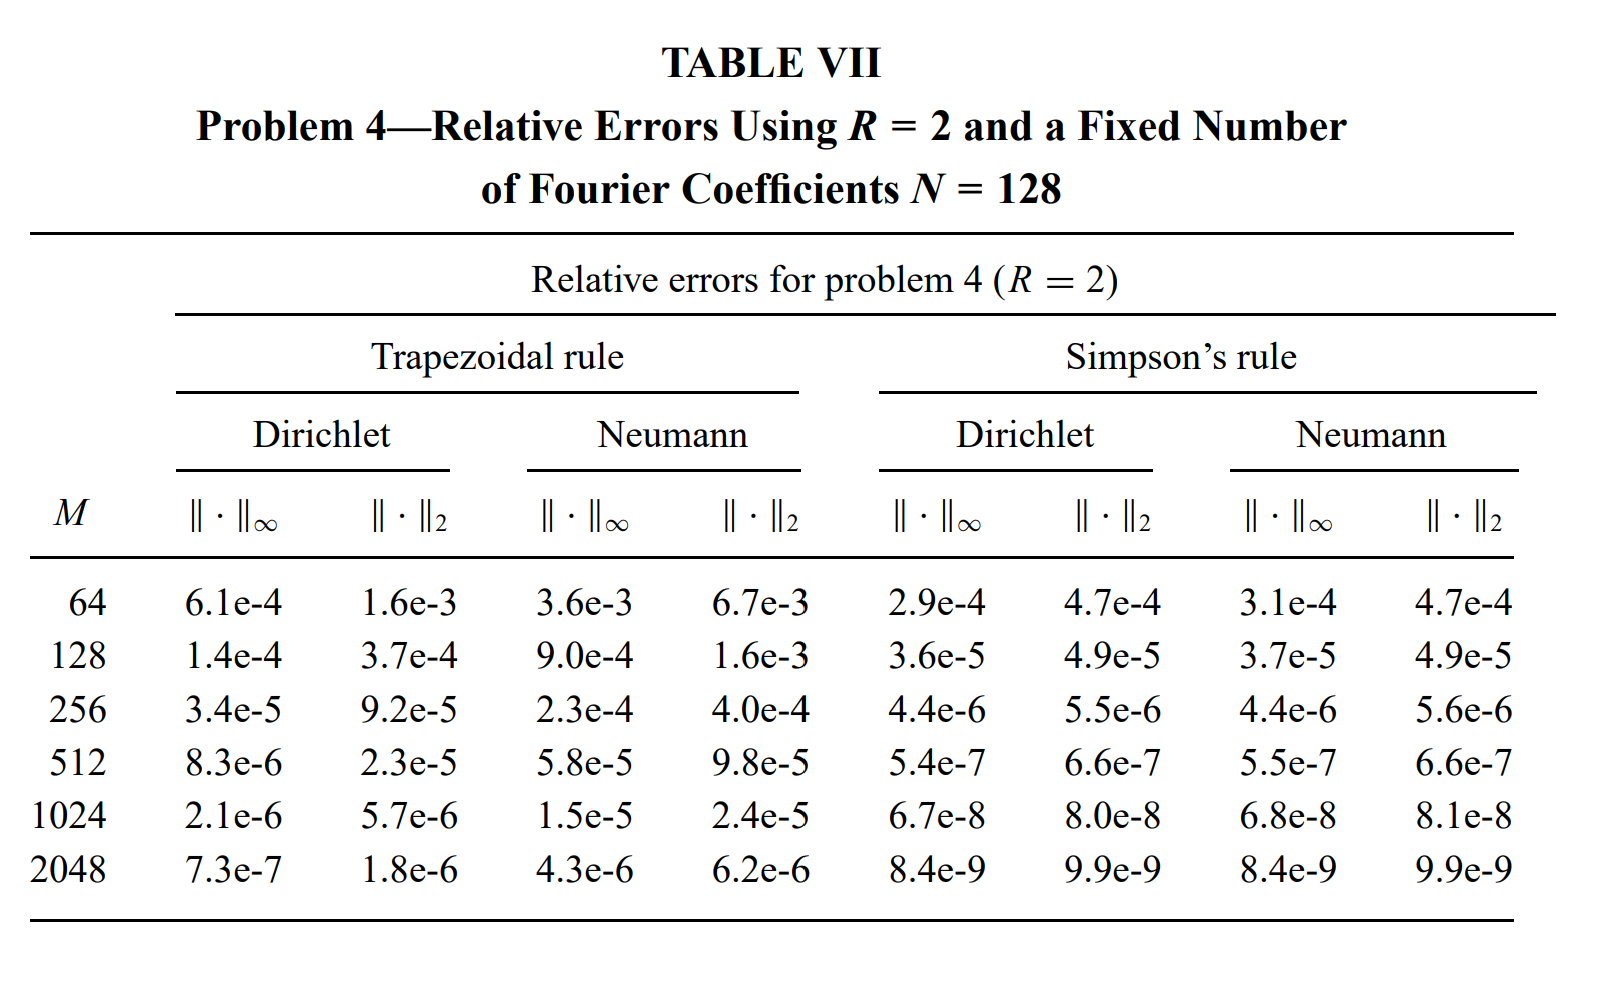